In [1]:
import pickle

import scanpy as sc
import numpy as np

import scvi
from benchmark_utils import (
    add_cell_types_grouped,
    preprocess_scrna,
    create_dirichlet_pseudobulk_dataset,
    create_latent_signature,
)

from benchmark_utils.latent_signature_utils import create_latent_signature

from constants import (
    N_GENES,
    TRAINING_CELL_TYPE_GROUP,
)

/home/owkin/deepdeconv-fork/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/owkin/deepdeconv-fork/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [2]:
with open("project/highest_r2_genes_3rd_gran.pkl", "rb") as f:
    filtered_genes = pickle.load(f)

mixup_model_path = "project/mixupvi_highest_r2_genes_3rd_gran"
scvi_model_path = "project/scvi_highest_r2_genes_3rd_gran"

## Load the CTI Dataset

In [3]:
cti_adata = sc.read("/home/owkin/project/cti/cti_adata.h5ad")
preprocess_scrna(cti_adata, keep_genes=N_GENES, batch_key="donor_id")
cell_type = f"cell_types_grouped_{TRAINING_CELL_TYPE_GROUP}"

cti_adata, train_test_index = add_cell_types_grouped(cti_adata, TRAINING_CELL_TYPE_GROUP)

cti_adata.obs["cell_types_grouped"] = cti_adata.obs[cell_type] #THIS SHOULD NOT BE DONE  

cti_adata_train = cti_adata[train_test_index["Train index"]]
cti_adata_test = cti_adata[train_test_index["Test index"]]

cti_adata_train = cti_adata_train[:, filtered_genes]

In [23]:
# Sample a small representative dataset with equal numbers of cells from each cell type group
n_cells_per_type = 50 # Number of cells to sample from each type
cell_types = cti_adata_train.obs[cell_type].unique()

sampled_indices = []
for ct in cell_types:
    ct_indices = cti_adata_train.obs[cti_adata_train.obs[cell_type] == ct].index
    if len(ct_indices) >= n_cells_per_type:
        sampled = np.random.choice(ct_indices, n_cells_per_type, replace=False)
    else:
        # If not enough cells, sample with replacement
        sampled = np.random.choice(ct_indices, n_cells_per_type, replace=True)
    sampled_indices.extend(sampled)

small_sc_dataset = cti_adata_train[sampled_indices].copy()


## Generating Pseudobulks with "mean" aggregation

In [5]:
pseudobulks_data_mean = create_dirichlet_pseudobulk_dataset(cti_adata_train, cell_type_group=cell_type, n_cells=256, n_sample = 200, aggregation_method="mean")
pseudobulks_data_mean["adata_pseudobulk_test_counts"]

AnnData object with n_obs × n_vars = 200 × 2000
    obs: 'donor_id', 'Predicted_labels_CellTypist', 'Majority_voting_CellTypist', 'Majority_voting_CellTypist_high', 'Manually_curated_celltype', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'cell_types_grouped_3rd_level_granularity', 'cell_types_grouped'
    layers: 'counts'

## Loading the models and create their latent representations

In [6]:
mixup_model = scvi.model.MixUpVI.load(mixup_model_path, cti_adata_train.copy())
scvi_model = scvi.model.SCVI.load(scvi_model_path, cti_adata_train.copy())

INFO     File project/mixupvi_highest_r2_genes_3rd_gran/model.pt already downloaded                                


No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


INFO     File project/scvi_highest_r2_genes_3rd_gran/model.pt already downloaded                                   


In [24]:
# Get latent representation of single cells
latent_sc_mixup = mixup_model.get_latent_representation(small_sc_dataset)
latent_sc_scvi = scvi_model.get_latent_representation(small_sc_dataset)
sc_cell_type = small_sc_dataset.obs[cell_type]

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [8]:
latent_pseudobulk_mean_mixup = mixup_model.get_latent_representation(pseudobulks_data_mean["adata_pseudobulk_test_counts"])
latent_pseudobulk_mean_scvi = scvi_model.get_latent_representation(pseudobulks_data_mean["adata_pseudobulk_test_counts"])

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


In [9]:
latent_signature_data_mean_mixup = create_latent_signature(adata=cti_adata_train, model=mixup_model, use_mixupvi=False, average_all_cells=True)
latent_signature_data_mean_scvi = create_latent_signature(adata=cti_adata_train, model=scvi_model, use_mixupvi=False, average_all_cells=True)

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                         

In [10]:
latent_signature_mean_mixup = latent_signature_data_mean_mixup.X
latent_signature_mean_scvi = latent_signature_data_mean_scvi.X

In [11]:
latent_signature_cell_type_mean_mixup = latent_signature_data_mean_mixup.obs["cell type"]
latent_signature_cell_type_mean_scvi = latent_signature_data_mean_scvi.obs["cell type"]

In [14]:
sc_cell_type.unique()

array(['Mem_CD8T', 'Macro', 'gdT', 'Mem_CD4T', 'NaiveB', 'Plasma',
       'Tregs', 'Naive_CD4T', 'DC', 'MemB', 'NK', 'Mono', 'Mast', 'pDC',
       'Naive_CD8T', 'ImmatureB'], dtype=object)

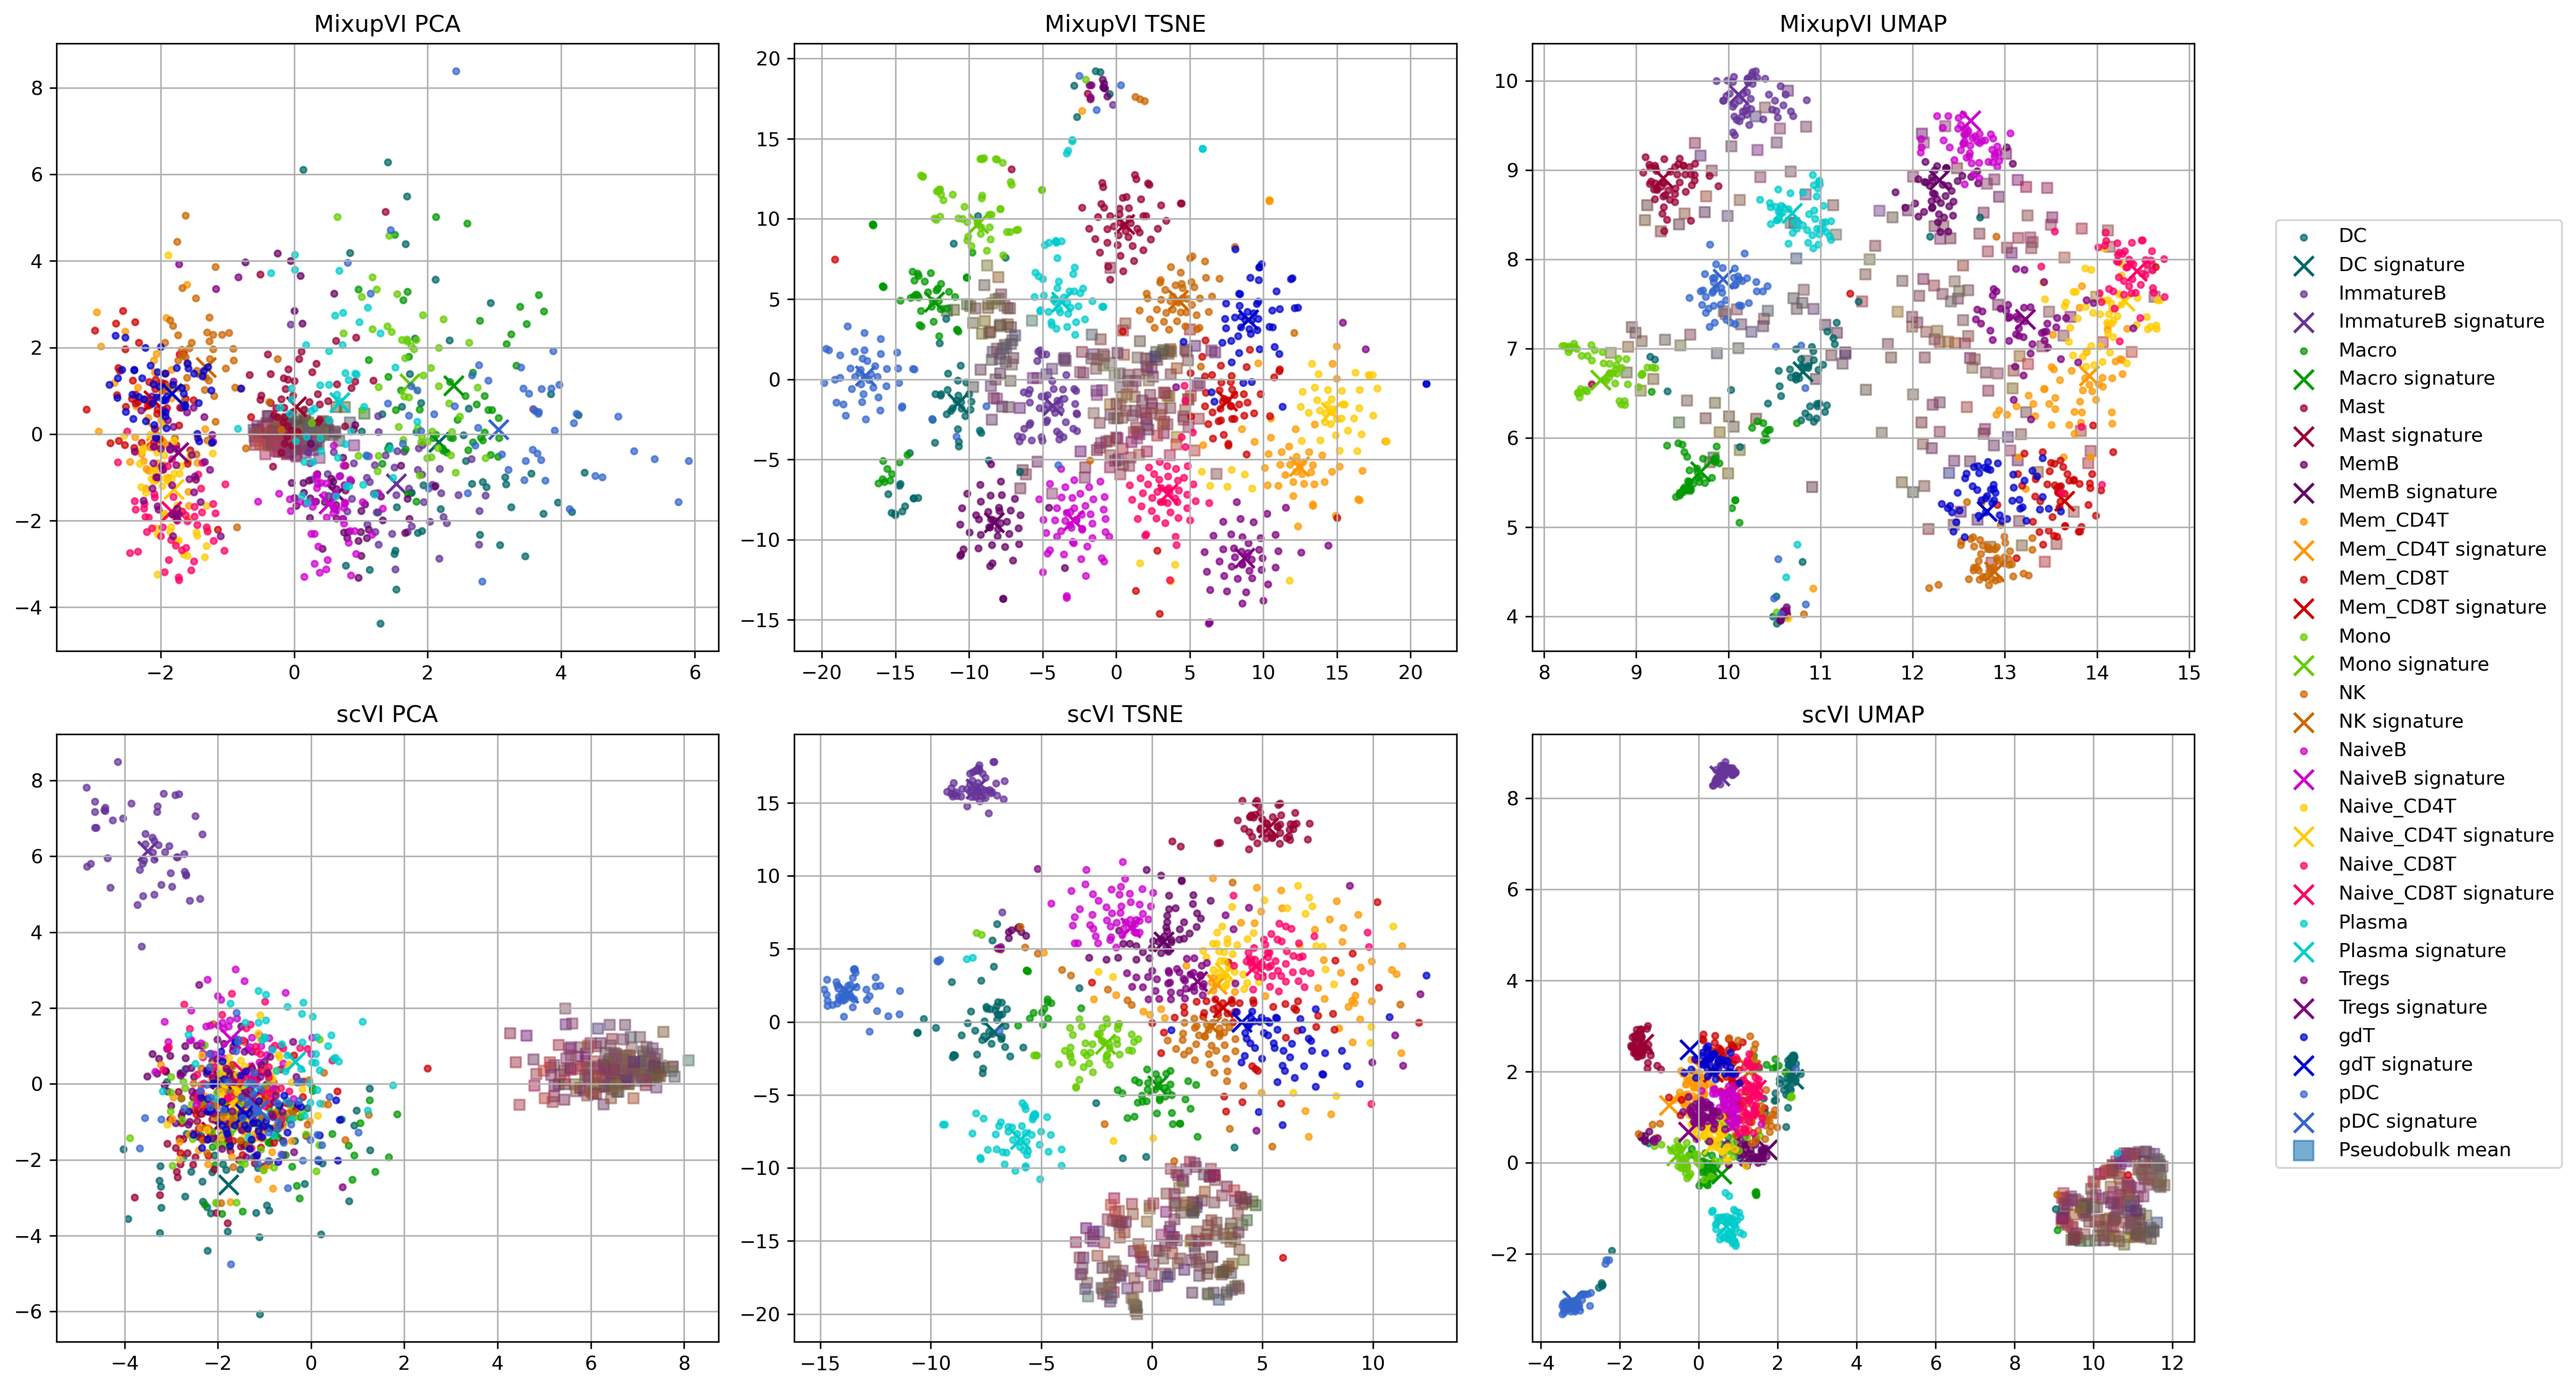

In [26]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import matplotlib.pyplot as plt

# Concatenate latent representations for MixupVI
all_latent_mixup = np.concatenate([
    latent_sc_mixup,
    latent_signature_mean_mixup,
    latent_pseudobulk_mean_mixup,
])

# Concatenate latent representations for scVI
all_latent_scvi = np.concatenate([
    latent_sc_scvi, 
    latent_signature_mean_scvi,
    latent_pseudobulk_mean_scvi,
])

# Initialize dimensionality reduction methods
pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=42)
umap = UMAP(n_components=2, random_state=42)

# Perform dimensionality reduction for both models
latent_2d_pca_mixup = pca.fit_transform(all_latent_mixup)
latent_2d_tsne_mixup = tsne.fit_transform(all_latent_mixup)
latent_2d_umap_mixup = umap.fit_transform(all_latent_mixup)

latent_2d_pca_scvi = pca.fit_transform(all_latent_scvi)
latent_2d_tsne_scvi = tsne.fit_transform(all_latent_scvi)
latent_2d_umap_scvi = umap.fit_transform(all_latent_scvi)

# Create figure with six subplots - now 2 rows, 3 columns
fig, axes = plt.subplots(2, 3, figsize=(16, 10), dpi=300)
titles = ['MixupVI', 'scVI']
methods = ['PCA', 'TSNE', 'UMAP']

# # Specific to FACS 1st granularity
# sc_colors = {
#     "B": np.array([0.0, 0.0, 1.0]),
#     "T": np.array([1.0, 0.0, 0.0]),
#     "Mono": np.array([0.0, 1.0, 0.0]),
#     "NK": np.array([0.0, 1.0, 1.0]),
#     "DC": np.array([1.0, 1.0, 0.0]),
# }

# Specific to 2nd granularity
# sc_colors = {
#     'CD4T': np.array([1.0, 0.0, 0.0]),     # Red
#     'CD8T': np.array([0.0, 1.0, 0.0]),     # Green
#     'B': np.array([0.0, 0.0, 1.0]),        # Blue
#     'Plasma': np.array([1.0, 0.0, 1.0]),   # Magenta
#     'DC': np.array([1.0, 1.0, 0.0]),       # Yellow
#     'NK': np.array([0.0, 1.0, 1.0]),       # Cyan
#     'Mono': np.array([1.0, 0.5, 0.0]),     # Orange
#     'Mast': np.array([0.5, 0.0, 1.0]),     # Purple
#     'Tregs': np.array([0.0, 0.5, 0.5])     # Teal
# }

# # Specific to 3rd granularity
sc_colors = {
    'Mem_CD8T': np.array([0.8, 0.0, 0.0]),      # Deep Red
    'Macro': np.array([0.0, 0.6, 0.0]),         # Forest Green  
    'gdT': np.array([0.0, 0.0, 0.8]),          # Deep Blue
    'Mem_CD4T': np.array([1.0, 0.6, 0.0]),     # Orange
    'NaiveB': np.array([0.8, 0.0, 0.8]),       # Magenta
    'Plasma': np.array([0.0, 0.8, 0.8]),       # Cyan
    'Tregs': np.array([0.5, 0.0, 0.5]),        # Purple
    'Naive_CD4T': np.array([1.0, 0.8, 0.0]),   # Gold
    'DC': np.array([0.0, 0.4, 0.4]),           # Teal
    'MemB': np.array([0.4, 0.0, 0.4]),         # Dark Purple
    'NK': np.array([0.8, 0.4, 0.0]),           # Brown
    'Mono': np.array([0.4, 0.8, 0.0]),         # Lime Green
    'Mast': np.array([0.6, 0.0, 0.2]),         # Burgundy
    'pDC': np.array([0.2, 0.4, 0.8]),          # Steel Blue
    'Naive_CD8T': np.array([1.0, 0.0, 0.4]),   # Hot Pink
    'ImmatureB': np.array([0.4, 0.2, 0.6])     # Lavender
}

# Helper function to plot on a given axis
def plot_latent_space(latent_2d, ax, title):
    # Get indices for different data types
    n_sc = len(latent_sc_mixup)
    n_signature = len(latent_signature_mean_mixup)
    
    # Plot pseudobulk points
    for i, row in enumerate(pseudobulks_data_mean["df_proportions_test"].iterrows()):
        pseudo_idx = n_sc + n_signature + i
        ax.scatter(latent_2d[pseudo_idx, 0], latent_2d[pseudo_idx, 1],
                  color= sum([row[1][key] * sc_colors[key] for key in row[1].index]), s=30, marker="s", alpha=0.5)
    
    unique_cell_types = np.unique(sc_cell_type)
    # Plot single cell points and signatures colored by cell type
    for i, cell_type in enumerate(unique_cell_types):
        # Plot single cells
        cell_mask = sc_cell_type == cell_type
        ax.scatter(latent_2d[:n_sc][cell_mask, 0], latent_2d[:n_sc][cell_mask, 1],
                  label=cell_type, alpha=0.7, s=10, color=sc_colors[cell_type])
        
        # Plot signatures
        sig_mask = latent_signature_cell_type_mean_mixup == cell_type
        sig_idx = n_sc + np.where(sig_mask)[0]
        ax.scatter(latent_2d[sig_idx, 0], latent_2d[sig_idx, 1],
                  label=f"{cell_type} signature", marker="x", s=100, color=sc_colors[cell_type])
        
    ax.scatter(None, None, label="Pseudobulk mean", s=100, marker="s", alpha=0.6)
    ax.set_title(title)
    ax.grid(True)

# Plot all visualizations
latent_2d_dict = {
    (0, 0): (latent_2d_pca_mixup, 'MixupVI PCA'),
    (1, 0): (latent_2d_pca_scvi, 'scVI PCA'),
    (0, 1): (latent_2d_tsne_mixup, 'MixupVI TSNE'),
    (1, 1): (latent_2d_tsne_scvi, 'scVI TSNE'),
    (0, 2): (latent_2d_umap_mixup, 'MixupVI UMAP'),
    (1, 2): (latent_2d_umap_scvi, 'scVI UMAP')
}

for (i, j), (latent_2d, title) in latent_2d_dict.items():
    plot_latent_space(latent_2d, axes[i, j], title)

# Add legend to the right of the figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.15, 0.5))

plt.tight_layout()
plt.show()
